# Introduction

- Date: 20250219
- The purpose of this notebook is to subcluster and perform Monocle on the Mesenchyme cells in the lung integrated object
- This was run on the Rnakato docker container

In [1]:
library(Seurat)
library(SeuratData)
library(SeuratDisk)
library(SeuratWrappers)
library(monocle3)
library(Matrix)
library(ggplot2)
library(cowplot)
#library(SingleR)
library(dplyr)
library(patchwork)
library(tidyr)
library(raster)
library(grid)
library(magrittr)

Attaching SeuratObject

Attaching sp

── Installed datasets ───────────────────────────────────── SeuratData v0.2.2 ──

✔ bmcite          0.3.0                 ✔ pbmcMultiome    0.1.2
✔ cbmc            3.1.4                 ✔ pbmcsca         3.0.0
✔ celegans.embryo 0.1.0                 ✔ ssHippo         3.1.4
✔ hcabm40k        3.0.0                 ✔ stxBrain        0.1.1
✔ ifnb            3.1.0                 ✔ stxKidney       0.1.0
✔ panc8           3.0.2                 ✔ thp1.eccite     3.1.5
✔ pbmc3k          3.1.4                 


────────────────────────────────────── Key ─────────────────────────────────────

✔ Dataset loaded successfully
❯ Dataset built with a newer version of Seurat than installed
❓ Unknown version of Seurat installed


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects 

In [2]:
data <- readRDS("/opt/work/Spatial_Lung/raw_data/scRNA/integrated/Lung_dbit_srf_CellReports_Science_integrated.RDS")

In [3]:
data

An object of class Seurat 
23663 features across 38340 samples within 1 assay 
Active assay: SCT (23663 features, 3000 variable features)
 3 dimensional reductions calculated: pca, integrated.dr, umap

# Subset and subcluster the Mesenchyme clusters

In [4]:
Idents(data) <- data$seurat_clusters
mes = subset(data, idents = c("0", '2', '3', '4', '5', '8', '11', '10', '15'))
mes$inte_seurat_clusters = mes$seurat_clusters

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 25377
Number of edges: 858153

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8420
Number of communities: 12
Elapsed time: 5 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
18:11:48 UMAP embedding parameters a = 0.9922 b = 1.112

18:11:48 Read 25377 rows and found 20 numeric columns

18:11:48 Using Annoy for neighbor search, n_neighbors = 30

18:11:48 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:11:50 Writing NN index file to temp file /tmp/Rtmplu3Ii6/filec5713a74a

18:11:50 Searching Annoy index using 1 thread, search_k = 3000

18:11:58 Annoy recall = 100%

18:11:58 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 3

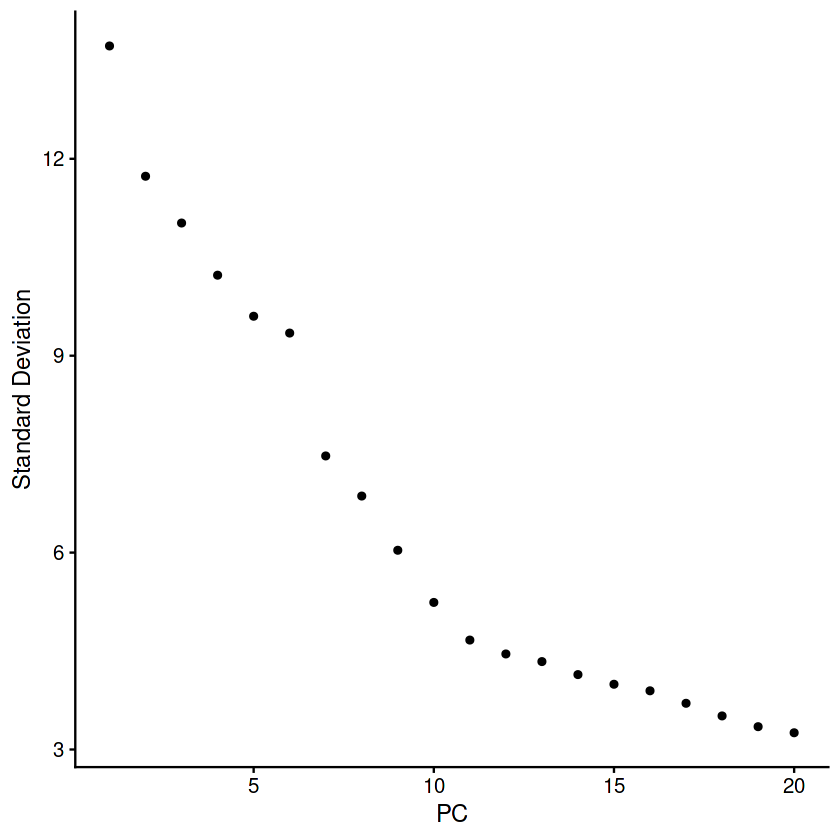

In [5]:
ElbowPlot(mes)
mes <- FindNeighbors(mes, reduction = "integrated.dr", dims = 1:20)
mes <- FindClusters(mes, resolution = 0.6)
mes <- RunUMAP(mes, dims = 1:20, reduction = 'integrated.dr')

In [6]:
pdf("/opt/work/Spatial_Lung/raw_data/scRNA/subcluster/integrated_mesenchyme_subcluster_QC.pdf")
DimPlot(mes, reduction = "umap",group.by = "tech", order =c("scRNA-seq","DBiT-seq") , cols = c("lightblue","red"))
DimPlot(mes, reduction = "umap",group.by = "orig.ident")
DimPlot(mes, reduction = "umap",group.by = "seurat_clusters", label = TRUE)
DimPlot(mes, reduction = "umap",group.by = "inte_seurat_clusters", label = TRUE)
features1 = c('ENSMUSG00000001496', 'ENSMUSG00000000567') # Nkx2-1, Sox9
features2 = c('ENSMUSG00000026586', 'ENSMUSG00000029838') # Prrx1, Ptn
features3 = c('ENSMUSG00000010797', 'ENSMUSG00000022836') # Wnt2, Mylk
features4 = c('ENSMUSG00000052187', 'ENSMUSG00000016458') #Hbb-y, Wt1
features5 = c('ENSMUSG00000024620', 'ENSMUSG00000039385') #Pdgfrb, Cdh6
features6 = c('ENSMUSG00000031871', 'ENSMUSG00000012520') #Cdh5, Phox2b
FeaturePlot(mes, features = features1) + ggtitle('Nkx2-1, Sox9') # Epithelial Markers
FeaturePlot(mes, features = features2) + ggtitle('Prrx1, Ptn') # Synthetic Mesenchyme and Precartilage
FeaturePlot(mes, features = features3) + ggtitle('Wnt2, Mylk') # Mesenchyme Progenitor and Smooth Muscle
FeaturePlot(mes, features = features4) + ggtitle('Hbb-y, Wt1') # Blood and Mesothelium
FeaturePlot(mes, features = features5) + ggtitle('Pdgfrb, Cdh6') # Pericyte and Neuron
FeaturePlot(mes, features = features6) + ggtitle('Cdh5', 'Phox2b') # Vascular Endothelial, Immune

test_ctrl_11R1 <- subset(x = mes, subset = orig.ident == "E11_iScience_R1")
test_ctrl_12 <- subset(x = mes, subset = orig.ident == 'E12_DevCell')
test_ctrl_12_cellR1 <- subset(x = mes, subset = orig.ident == 'E12_CellReports_R1')
test_ctrl_12_science <- subset(x = mes, subset = orig.ident == 'E12_Science')
test_ctrl_13_cell <- subset(x = mes, subset = orig.ident == 'E13_CellReports')
test_dbit <- subset(x = mes, subset = tech == 'DBiT_seq')

DimPlot(test_ctrl_11R1, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E11_iScience_R1')
#DimPlot(test_ctrl_11R2, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E11_iScience_R2')
DimPlot(test_ctrl_12, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12ctrl') 
DimPlot(test_ctrl_12_cellR1, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12CellReports_rep1') 
DimPlot(test_ctrl_12_science, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12Science') 
DimPlot(test_ctrl_13_cell, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E13CellReports') 
graphics.off()

In [7]:
saveRDS(mes, file = "/opt/work/Spatial_Lung/raw_data/scRNA/subcluster/Lung_integrated_mesenchyme_subcluster.RDS")

In [9]:
# Save the sct slot to an h5ad
i <- sapply(mes@meta.data, is.factor)
mes@meta.data[i] <- lapply(mes@meta.data[i], as.character)

SaveH5Seurat(mes, filename = "/opt/work/Spatial_Lung/raw_data/scRNA/subcluster/Lung_integrated_mesenchyme_subset.h5Seurat")
Convert("/opt/work/Spatial_Lung/raw_data/scRNA/subcluster/Lung_integrated_mesenchyme_subset.h5Seurat", dest = 'h5ad')

Creating h5Seurat file for version 3.1.5.9900

Adding counts for SCT

Adding data for SCT

Adding scale.data for SCT

Adding variable features for SCT

No feature-level metadata found for SCT

Writing out SCTModel.list for SCT

Adding cell embeddings for pca

Adding loadings for pca

No projected loadings for pca

Adding standard deviations for pca

No JackStraw data for pca

Adding cell embeddings for integrated.dr

Adding loadings for integrated.dr

No projected loadings for integrated.dr

No standard deviations for integrated.dr

No JackStraw data for integrated.dr

Adding cell embeddings for umap

No loadings for umap

No projected loadings for umap

No standard deviations for umap

No JackStraw data for umap

Validating h5Seurat file

Warning message:
“Cannot find assayRNA in the h5Seurat file”
Adding scale.data from SCT as X

Adding data from SCT as raw

Transfering meta.data to obs

Adding dimensional reduction information for integrated.dr

Adding feature loadings for integrate

In [7]:
# convert the data to a cds
cds <- as.cell_data_set(mes)
#saveRDS(cds, file = "Lung_dbit_srf_CellReports_Science_integrated_cds.RDS")

Warning message:
“Monocle 3 trajectories require cluster partitions, which Seurat does not calculate. Please run 'cluster_cells' on your cell_data_set object”


In [8]:
rm(data)

# Run Monocle on the cds

In [9]:
library(monocle3)
library(ggplot2)
library(patchwork)
library(dplyr)
library(Matrix)
library(irlba)

In [10]:
cds <- preprocess_cds(cds)

In [11]:
rowData(cds)$gene_name <- rownames(cds)
rowData(cds)$gene_short_name <- rowData(cds)$gene_name

In [12]:
cds

class: cell_data_set 
dim: 23663 25377 
metadata(0):
assays(2): counts logcounts
rownames(23663): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000093903 ENSMUSG00000121343
rowData names(2): gene_name gene_short_name
colnames(25377): AAACCCAAGGCATTTC-1_1 AAACCCACAGACAAAT-1_1 ...
  TTTGTCACAGACTCGC-1_18 TTTGTCACATGTCTCC-1_18
colData names(16): orig.ident nCount_RNA ... ident Size_Factor
reducedDimNames(3): PCA INTEGRATED.DR UMAP
mainExpName: SCT
altExpNames(0):

# Run Monocle and module analysis on the dataset

In [13]:
dir <- "/opt/work/Spatial_Lung/sandbox/scRNA/pseudotime/mesenchyme_subcluster/"  
setwd(dir)

In [14]:
mes_cds <- cds

In [15]:
mes_cds <- cluster_cells(cds = mes_cds, cluster_method = 'louvain', reduction_method = 'UMAP')
mes_cds <- learn_graph(mes_cds, learn_graph_control = list(minimal_branch_len = 25))
pdf('Lung_mesenchyme_subcluster_pseudotime_plots.pdf')
p1 <- plot_cells(mes_cds, color_cells_by = 'seurat_clusters', label_groups_by_cluster = FALSE, label_leaves = FALSE, label_branch_points = FALSE)
print(p1)
p2 <- plot_cells(mes_cds, color_cells_by = 'orig.ident', label_groups_by_cluster = FALSE, label_leaves = FALSE, label_branch_points = FALSE)
print(p2)
p3 <- plot_cells(mes_cds, show_trajectory_graph = TRUE,  label_principal_points = TRUE)
print(p3)
graphics.off()

  |======================================================================| 100%


In [16]:
mes_cds <- order_cells(mes_cds, reduction_method = 'UMAP', root_pr_nodes = c('Y_724', 'Y_324'))
pdf('Lung_mesenchyme_subcluster_trajectory.pdf')
p3 <- plot_cells(cds = mes_cds, color_cells_by = "pseudotime", show_trajectory_graph = TRUE)
print(p3)
graphics.off()

Cells aren't colored in a way that allows them to be grouped.



In [17]:
traj.coord <- mes_cds@principal_graph_aux@listData[['UMAP']][['pseudotime']]
write.table(traj.coord, 'Lung_mesenchyme_subcluster_integrated_monocle_pos.txt', append = FALSE, sep = '\t', dec = '.', row.names = TRUE, col.names = TRUE)

In [18]:
# Use graph test to find genes that vary significantly over the pseudotime
mes_graph_test_res <- graph_test(mes_cds, neighbor_graph="knn", cores=4)

  |=======================================================| 100%, Elapsed 32:45


In [21]:
# Identify the genes that vary significantly
mes_deg_ids <- row.names(subset(mes_graph_test_res, q_value < 0.05))
mes_deg_ids_above_0.1 <- row.names(subset(mes_graph_test_res, morans_I > 0.1))
# Save the different gene lists to txt files
write.csv(mes_deg_ids_above_0.1, "Lung_mesenchyme_subcluster_monocle_full_subset_graph_test_genes_above_0.1morans.txt")
write.csv(mes_graph_test_res, "Lung_mesenchyme_subcluster_monocle_full_subset_graph_test_results.txt")

In [23]:
# Find modules across the full subset at high clustering resolution and the full / filtered set of genes
mes_top_genes_gene_module_df <- find_gene_modules(mes_cds[mes_deg_ids_above_0.1,], resolution=c(10^seq(-7,-1))) # this tests many resolutiosn and selects the best one

In [24]:
# save all the tables
write.csv(mes_top_genes_gene_module_df, "Lung_mesenchyme_subcluster_monocle_gene_modules_genes_above_0.1morans.txt")

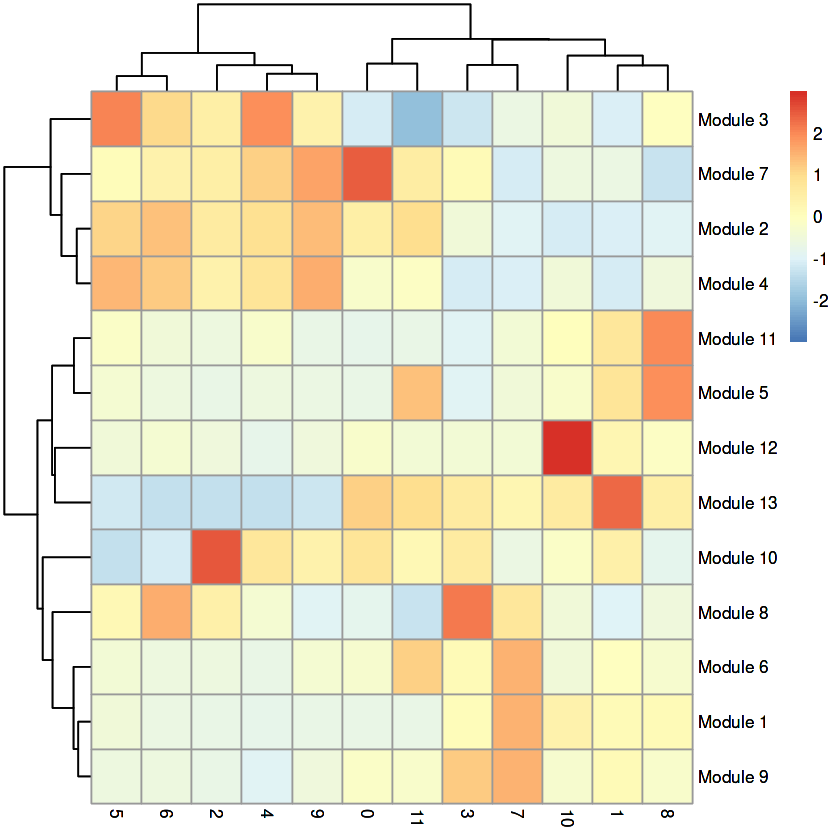

In [25]:
# graph the aggregate expression against cell states
mes_cell_group_df <- tibble::tibble(cell=row.names(colData(mes_cds)), cell_group=colData(mes_cds)$seurat_clusters)

agg_mat <- aggregate_gene_expression(mes_cds, mes_top_genes_gene_module_df, mes_cell_group_df)
row.names(agg_mat) <- stringr::str_c("Module ", row.names(agg_mat))
p1 <- pheatmap::pheatmap(agg_mat, scale="column", clustering_method="ward.D2")
p1

In [26]:
# Plot all the modules for the low res, all genes, in the full subset of cell types
pdf("Lung_mesenchyme_subcluster_monocle_modules_top_genes.pdf")
plot_cells(mes_cds, genes = mes_top_genes_gene_module_df %>% filter(module %in% c(1, 2, 3, 4, 5, 6, 7, 8)), label_cell_groups=FALSE, show_trajectory_graph=FALSE)
plot_cells(mes_cds, genes = mes_top_genes_gene_module_df %>% filter(module %in% c(9, 10, 11, 12, 13)), label_cell_groups=FALSE, show_trajectory_graph=FALSE)
dev.off()

Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”


png 
  2

# Run Monocle and module analysis on the Synthetic Mesenchyme trajectory

- This will include our 'SyntheticMesenchyme' cluster (1, 8), and MesenchymeProgenitor (9, 0, 2, 5, 4)# Run monocle analysis for the Distal epithelial trajectory

In [13]:
dir <- "/opt/work/Spatial_Lung/sandbox/scRNA/pseudotime/synthetic_mesenchyme_subcluster/"  
setwd(dir)

In [14]:
# Subset just the synthetic mesenchyme clusters
syn_cds <- cds[rowData(cds)$gene_short_name,
               colData(cds)$seurat_clusters %in% c('1', '8', '9', '0', '2', '5', '4')]

In [15]:
syn_cds <- cluster_cells(cds = syn_cds, cluster_method = 'louvain', reduction_method = 'UMAP')
syn_cds <- learn_graph(syn_cds, learn_graph_control = list(minimal_branch_len = 25))
pdf('Lung_synthetic_mesenchyme_subcluster_pseudotime_plots.pdf')
p1 <- plot_cells(syn_cds, color_cells_by = 'seurat_clusters', label_groups_by_cluster = FALSE, label_leaves = FALSE, label_branch_points = FALSE)
print(p1)
p2 <- plot_cells(syn_cds, color_cells_by = 'orig.ident', label_groups_by_cluster = FALSE, label_leaves = FALSE, label_branch_points = FALSE)
print(p2)
p3 <- plot_cells(syn_cds, show_trajectory_graph = TRUE,  label_principal_points = TRUE)
print(p3)
graphics.off()

  |======================================================================| 100%


In [16]:
syn_cds <- order_cells(syn_cds, reduction_method = 'UMAP', root_pr_nodes = c('Y_123', 'Y_197'))
pdf('Lung_synthetic_mesenchyme_subcluster_trajectory.pdf')
p3 <- plot_cells(cds = syn_cds, color_cells_by = "pseudotime", show_trajectory_graph = TRUE)
print(p3)
graphics.off()

Cells aren't colored in a way that allows them to be grouped.



In [17]:
traj.coord <- syn_cds@principal_graph_aux@listData[['UMAP']][['pseudotime']]
write.table(traj.coord, 'Lung_synthetic_mesenchyme_subcluster_integrated_monocle_pos.txt', append = FALSE, sep = '\t', dec = '.', row.names = TRUE, col.names = TRUE)

In [18]:
# Use graph test to find genes that vary significantly over the pseudotime
syn_graph_test_res <- graph_test(syn_cds, neighbor_graph="knn", cores=4)

  |=======================================================| 100%, Elapsed 22:05


In [19]:
# Identify the genes that vary significantly
syn_deg_ids <- row.names(subset(syn_graph_test_res, q_value < 0.05))
syn_deg_ids_above_0.1 <- row.names(subset(syn_graph_test_res, morans_I > 0.1))
# Save the different gene lists to txt files
write.csv(syn_deg_ids_above_0.1, "Lung_synthetic_mesenchyme_subcluster_monocle_full_subset_graph_test_genes_above_0.1morans.txt")
write.csv(syn_graph_test_res, "Lung_synthetic_mesenchyme_subcluster_monocle_full_subset_graph_test_results.txt")

In [20]:
# Find modules across the full subset at high clustering resolution and the full / filtered set of genes
syn_top_genes_gene_module_df <- find_gene_modules(syn_cds[syn_deg_ids_above_0.1,], resolution=c(10^seq(-7,-1))) # this tests many resolutiosn and selects the best one

In [21]:
# save all the tables
write.csv(syn_top_genes_gene_module_df, "Lung_synthetic_mesenchyme_subcluster_monocle_gene_modules_genes_above_0.1morans.txt")

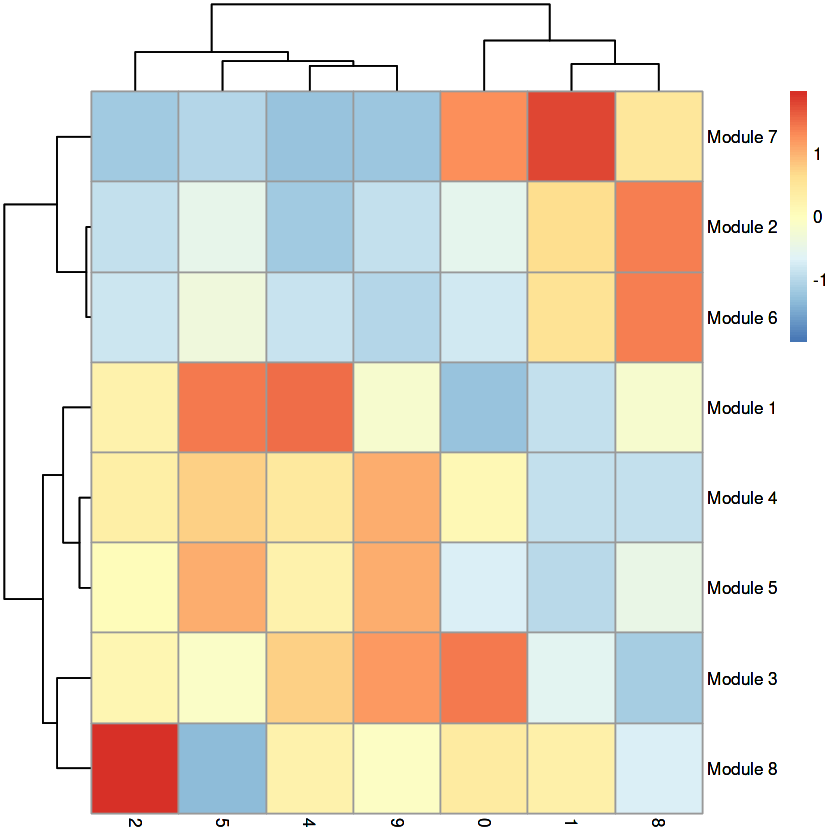

In [22]:
# graph the aggregate expression against cell states
syn_cell_group_df <- tibble::tibble(cell=row.names(colData(syn_cds)), cell_group=colData(syn_cds)$seurat_clusters)

agg_mat <- aggregate_gene_expression(syn_cds, syn_top_genes_gene_module_df, syn_cell_group_df)
row.names(agg_mat) <- stringr::str_c("Module ", row.names(agg_mat))
p1 <- pheatmap::pheatmap(agg_mat, scale="column", clustering_method="ward.D2")
p1

In [23]:
# Plot all the modules for the low res, all genes, in the full subset of cell types
pdf("Lung_synthetic_mesenchyme_subcluster_monocle_modules_top_genes.pdf")
plot_cells(syn_cds, genes = syn_top_genes_gene_module_df %>% filter(module %in% c(1, 2, 3, 4, 5, 6, 7, 8)), label_cell_groups=FALSE, show_trajectory_graph=FALSE)
dev.off()

Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”


png 
  2

In [24]:
rm(syn_cds)

# Run Monocle and module analysis on the smooth muscle trajectory
- This will include our smooth muscle states (3, 7), and the MP1 state (0, 2, 9)

In [25]:
dir <- "/opt/work/Spatial_Lung/sandbox/scRNA/pseudotime/smooth_muscle_subcluster/"  
setwd(dir)

In [26]:
sm_cds <- cds[rowData(cds)$gene_short_name,
               colData(cds)$seurat_clusters %in% c("0", '2', '9', '3', '7')]

In [27]:
sm_cds <- cluster_cells(cds = sm_cds, cluster_method = 'louvain')
sm_cds <- learn_graph(sm_cds, learn_graph_control = list(minimal_branch_len = 35))
pdf('Lung_smooth_muscle_subcluster_integrated_pseudotime_plots.pdf')
p1 <- plot_cells(sm_cds, color_cells_by = 'seurat_clusters', label_groups_by_cluster = FALSE, label_leaves = FALSE, label_branch_points = FALSE)
print(p1)
p2 <- plot_cells(sm_cds, color_cells_by = 'orig.ident', label_groups_by_cluster = FALSE, label_leaves = FALSE, label_branch_points = FALSE)
print(p2)
p3 <- plot_cells(sm_cds, show_trajectory_graph = TRUE,  label_principal_points = TRUE)
print(p3)
graphics.off()

  |======================================================================| 100%


Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [28]:
sm_cds <- order_cells(sm_cds, reduction_method = 'UMAP', root_pr_nodes = c('Y_315'))
pdf('Lung_smooth_muscle_subcluster_integrated_trajectory.pdf')
p3 <- plot_cells(cds = sm_cds, color_cells_by = "pseudotime", show_trajectory_graph = TRUE)
print(p3)
graphics.off()

Cells aren't colored in a way that allows them to be grouped.



In [29]:
traj.coord <- sm_cds@principal_graph_aux@listData[['UMAP']][['pseudotime']]
write.table(traj.coord, 'Lung_smooth_muscle_subcluster_integrated_monocle_pos.txt', append = FALSE, sep = '\t', dec = '.', row.names = TRUE, col.names = TRUE)

In [30]:
# Use graph test to find genes that vary significantly over the pseudotime
sm_graph_test_res <- graph_test(sm_cds, neighbor_graph="knn", cores=4)

  |=======================================================| 100%, Elapsed 17:57


In [31]:
# Identify the genes that vary significantly
sm_deg_ids <- row.names(subset(sm_graph_test_res, q_value < 0.05))
sm_deg_ids_above_0.1 <- row.names(subset(sm_graph_test_res, morans_I > 0.1))
# Save the different gene lists to txt files
write.csv(sm_deg_ids_above_0.1, "Lung_smooth_muscle_subcluster_monocle_graph_test_genes_above_0.1morans.txt")
write.csv(sm_graph_test_res, "Lung_smooth_muscle_subcluster_monocle_graph_test_results.txt")

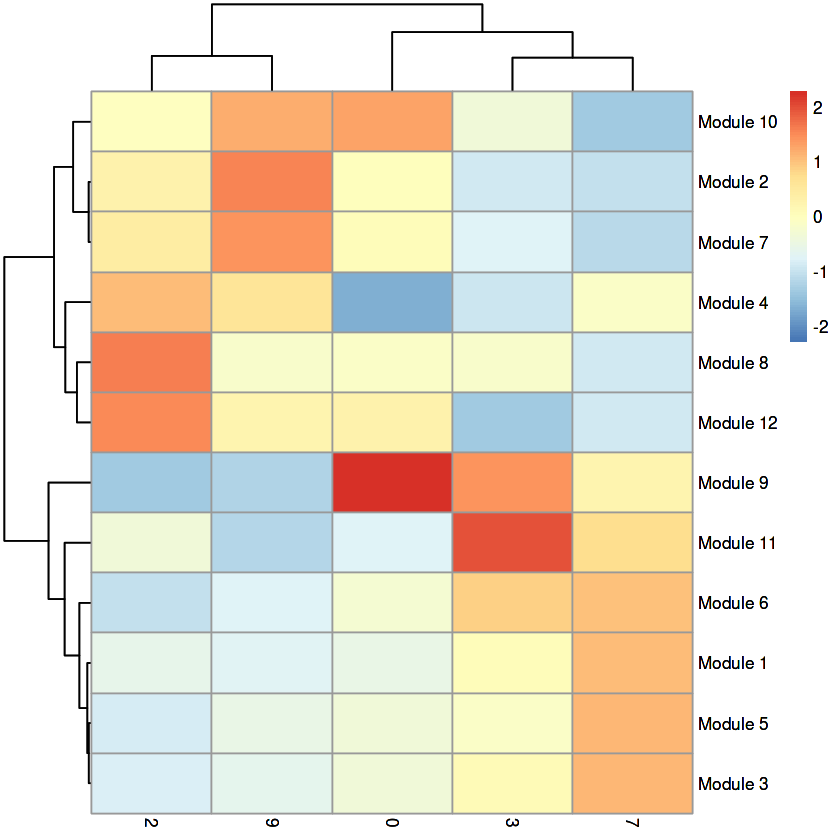

In [32]:
# Find modules across the full subset at high clustering resolution and the full / filtered set of genes
sm_top_genes_gene_module_df <- find_gene_modules(sm_cds[sm_deg_ids_above_0.1,], resolution=c(10^seq(-7,-1))) # this tests many resolutiosn and selects the best one

# save all the tables
write.csv(sm_top_genes_gene_module_df, "Lung_smooth_muscle_subcluster_monocle_gene_modules_genes_above_0.1morans.txt")

# graph the aggregate expression against cell states
sm_cell_group_df <- tibble::tibble(cell=row.names(colData(sm_cds)), cell_group=colData(sm_cds)$seurat_clusters)

agg_mat <- aggregate_gene_expression(sm_cds, sm_top_genes_gene_module_df, sm_cell_group_df)
row.names(agg_mat) <- stringr::str_c("Module ", row.names(agg_mat))
p1 = pheatmap::pheatmap(agg_mat, scale="column", clustering_method="ward.D2")
p1

In [33]:
# Plot all the modules for the low res, all genes, in the full subset of cell types
pdf("Lung_smooth_muscle_monocle_modules_top_genes.pdf")
plot_cells(sm_cds, genes = sm_top_genes_gene_module_df %>% filter(module %in% c(1, 2, 3, 4, 5, 6, 7, 8, 9)), label_cell_groups=FALSE, show_trajectory_graph=FALSE)
plot_cells(sm_cds, genes = sm_top_genes_gene_module_df %>% filter(module %in% c(10, 11, 12)), label_cell_groups=FALSE, show_trajectory_graph=FALSE)
graphics.off()

Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
Warning message in !is.null(dim(genes)) && dim(genes) >= 2:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”
